In [41]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

## Practica 3
## Parte 1 (ECG)

In [42]:
#Implementacion de funcion, se procede a crear la funcion para calcular el valor cuadratico medio (RMS)
def calcular_rms(x):
    x = np.array(x)          # Convertir la señal a arreglo
    N = len(x)               # Número de muestras
    rms = np.sqrt(np.sum(x**2) / N)
    return rms

In [43]:
#Se carga la base de datos suministrada y se muestran las keys que tiene para observar la distribucion de los datos.
data = loadmat(r'C:\UdeA\Semestre 20261\Bioseñales\signals.mat')

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [44]:
#Se extraen las señales solicitadas.
ecg_raw = data['ECG_asRecording'].flatten()
ecg_filt = data['ECG_filtered'].flatten()

In [45]:
#Se obtiene la frecuencia de muestro y el numero de muestras con el fin de encontrar la duracion o el periodo.
fs = data['Fs'][0][0]   # frecuencia de muestreo
N = len(ecg_raw)

print("Número de muestras:", N)
print("Frecuencia de muestreo:", fs)

Número de muestras: 30720
Frecuencia de muestreo: 1024


In [46]:
#Para hallar la duracion se usa la formula de, # de muestras / Frecuencia de muestreo.
duracion = N / fs

print(f"Duración de la señal: {duracion} segundos")

Duración de la señal: 30.0 segundos


In [47]:
#Se crea el vector de tiempo que fue solicitado.
t = np.arange(N) / fs

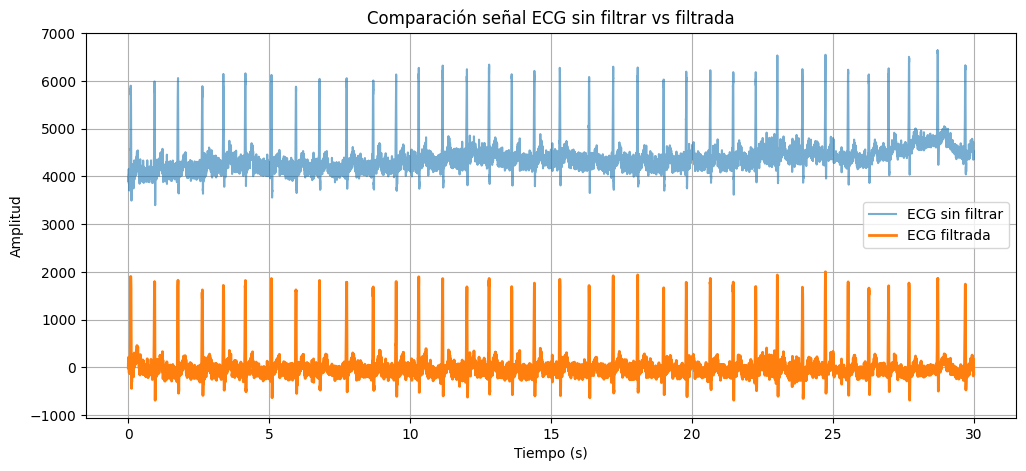

In [48]:
#Se procede a graficar la señal filtrada y la original, con el fin de realizar un analisis. 
plt.figure(figsize=(12,5))

plt.plot(t, ecg_raw, label="ECG sin filtrar", alpha=0.6)
plt.plot(t, ecg_filt, label="ECG filtrada", linewidth=2)

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación señal ECG sin filtrar vs filtrada")
plt.legend()
plt.grid()

plt.show()


# **1) Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.**

R/ En la figura anterior se observan dos señales, la señal original en azul y la filtrada en naranja. En la señal sin filtrar se observa una mayor presencia de ruido y se nota un desplazada hacia arriba, por otro lado, en la señal filtrada, la línea base se estabiliza alrededor de cero y el ruido de alta frecuencia disminuye, lo que permite observar con mayor claridad los complejos QRS y la morfología general del ECG. Segun lo anterior, se puede concluir que el filtro que se uso es un pasabajas o en su defecto un pasabandas, ademas, se sabe que las frecuencias de interés en un electrocardiograma (ECG) abarcan principalmente un rango que es crucial para una evaluación cardíaca precisa, estos funcionan convencionalmente dentro de un rango de frecuencias de 0,05 a 150 Hz, pero los avances tecnológicos han permitido explorar frecuencias más altas, especialmente en el complejo QRS, que pueden extenderse hasta 1000 Hz [1]. Por esta razon, es logico pensar en usar un filtro pasabajas o si se quiere ser mas estricto, se puede usar un pasabanda.


## Refencia:

[1] E. Trägårdh and T. T. Schlegel, “High-frequency ECG,” Jan. 2006, [Online]. Available: https://ntrs.nasa.gov/archive/nasa/casi.ntrs.nasa.gov/20060056493.pdf

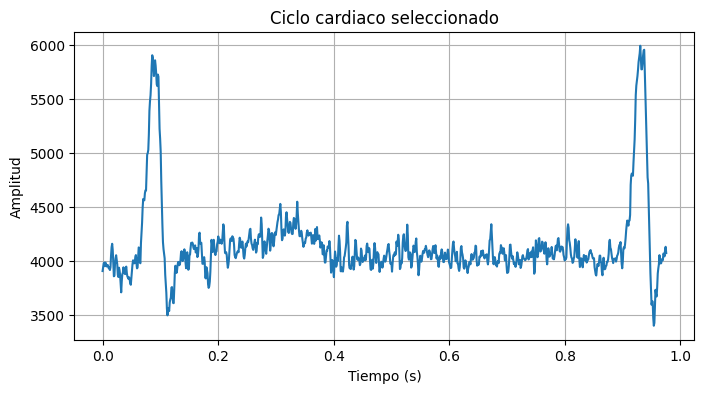

In [49]:
#Se selecciona un ciclo de la señal original, y se grafica.
inicio = 0
fin = 1000

ciclo = ecg_raw[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Ciclo cardiaco seleccionado")
plt.grid()
plt.show()

In [50]:
#Se sacan las metricas solicitadas para un analisis previo.
promedio = np.mean(ciclo)
rms = calcular_rms(ciclo)
varianza = np.var(ciclo)
desv_std = np.std(ciclo)

print("Promedio:", promedio)
print("RMS:", rms)
print("Varianza:", varianza)
print("Desviación estándar:", desv_std)

Promedio: 4146.573967773437
RMS: 4163.041009634786
Varianza: 136834.77768466578
Desviación estándar: 369.9118512357583


# **2) Analizar los resultados**

R/ El ciclo cardíaco presenta un promedio de 4146.57, esto indica que la señal está desplazada respecto a cero debido a un nivel DC o por la línea base del sistema de adquisición, esto mismo se puede apreciar en la grafica. El valor RMS (4163.04) es muy cercano al promedio, esto indica que la señal tiene una variabilidad baja y es probable que sea consistente, lo que sugiere que la potencia de la señal es estable y no está sujeta a fluctuaciones significativas [2]. La varianza (136834.78) y la desviación estándar (369.91) reflejan el grado de dispersión con respecto a su media, lo que indica qué tan dispersos están los valores y  una medida de la variabilidad en las mismas unidades que los datos originales, respectivamente [3]. Entonces, en conjunto, estos resultados indican que el ciclo presenta variaciones moderadas respecto a su línea base, donde los picos del latido cardíaco son los principales responsables de la variabilidad observada en la señal.

## Refencias:

[2] W. C. Y. Lee, “Finding the RMS Value of a Fading Signal Directly and Quickly from Its Decibel Values,” IEEE Transactions on Instrumentation and Measurement, vol. 18, no. 4, pp. 321–326, Dec. 1969, doi: 10.1109/TIM.1969.4313830.

[3] L. Yu, G. He, and A. K. Mutahir, “N-Step Sliding Recursion Formula of Variance and Its Implementation.”, doi: 10.3745/jips.04.0182.


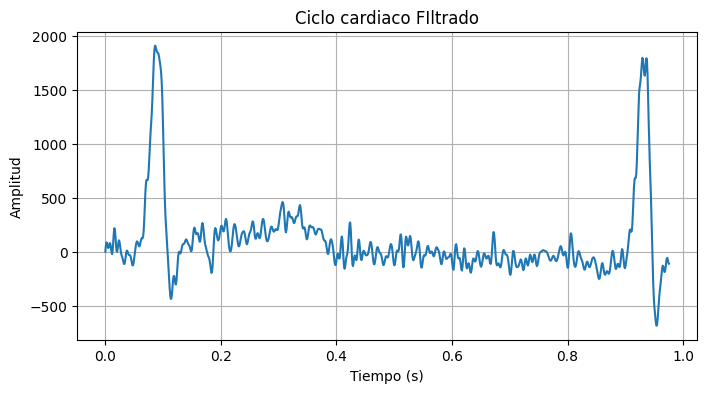

In [51]:
#Se realiza el mismo procedimiento que con la señal original, solo que ahora es con la filtrada.
inicio = 0
fin = 1000

ciclo_filt = ecg_filt[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo_filt)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Ciclo cardiaco FIltrado")
plt.grid()
plt.show()

In [52]:
#Se vuelven a calcular las metricas solicitadas para un analisis.
promedio_f = np.mean(ciclo_filt)
rms_f = calcular_rms(ciclo_filt)
varianza_f = np.var(ciclo_filt)
desv_std_f = np.std(ciclo_filt)

print("Promedio:", promedio_f)
print("RMS:", rms_f)
print("Varianza:", varianza_f)
print("Desviación estándar:", desv_std_f)

Promedio: 98.76212104547919
RMS: 388.95193143334086
Varianza: 141529.6484123244
Desviación estándar: 376.20426421337174


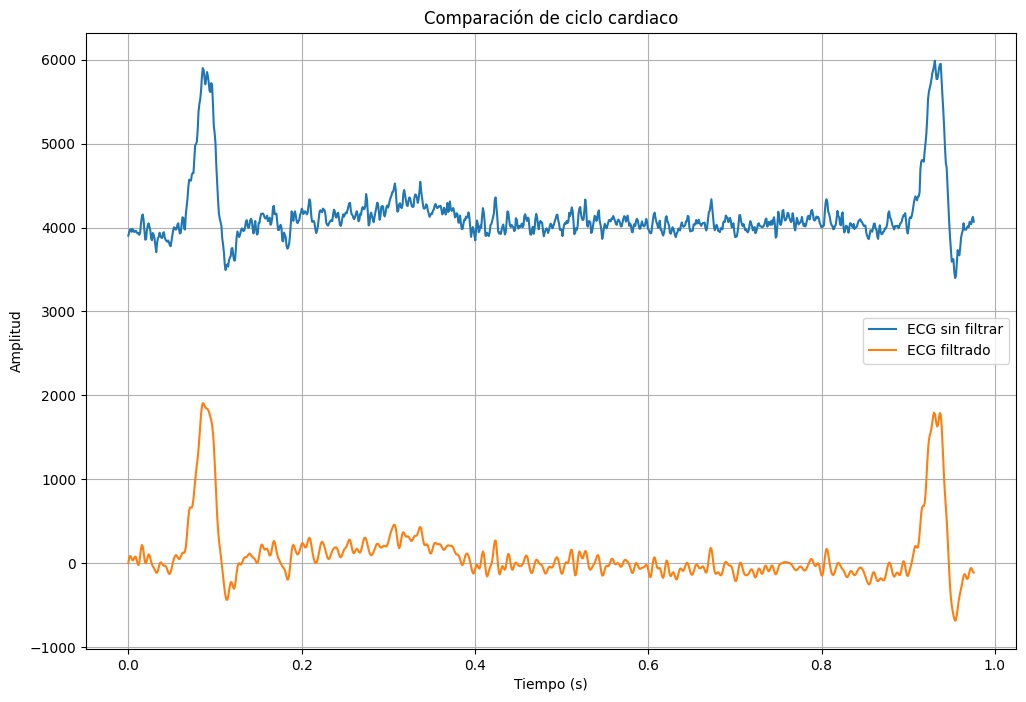

In [53]:
#Se muestan los ciclos de la señal pasada, tanto de la original como de la filtada, con el fin de realizar un analisis comparativo.
plt.figure(figsize=(12,8))

plt.plot(t_ciclo, ciclo, label="ECG sin filtrar")
plt.plot(t_ciclo, ciclo_filt, label="ECG filtrado")

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación de ciclo cardiaco")
plt.legend()
plt.grid()

plt.show()

# **3) Compara resultados de los dos señales y sus metricas.**

R/ Al comparar los resultados de la señal original con los de la señal filtrada se observa un cambio importante en el promedio, que pasa de aproximadamente 4146.57 a 98.76. Esto indica que el filtrado eliminó gran parte del nivel DC que tiene la señal original, esto centró la señal alrededor de valores cercanos a cero. El valor RMS disminuye de 4163.04 a 388.95, esto refleja una reducción significativa de la energía total de la señal, la cual se encontraba principalmente asociada al nivel DC que esta tenia. Por otro lado, la varianza y la desviación estándar se mantienen casi iguales, esto indica que la variabilidad producida por las ondas del complejo QRS, se conserva después del filtrado. Se puede concluir que el filtro eliminó componentes no deseados como el nivel DC, pero preservó la información fisiológica relevante de la señal cardíaca.


In [54]:
#Se proceden a extraer 15 ciclos de la señal filtrada para los cuales se obtendran las metricas solicitadas para cada uno.
peaks, _ = find_peaks(ecg_filt, distance=0.6*fs)

ciclos = []
promedios = []
varianzas = []

for i in range(15):
    inicio = peaks[i]
    fin = peaks[i+1]
    ciclo = ecg_filt[inicio:fin]
    ciclos.append(ciclo)

for ciclo in ciclos:
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

In [55]:
for i in range(15):
    print(f"Ciclo {i+1}")
    print("Promedio:", promedios[i])
    print("Varianza:", varianzas[i])
    print()

Ciclo 1
Promedio: 74.00995782055861
Varianza: 96684.31488232457

Ciclo 2
Promedio: -1.4625781779933433
Varianza: 104790.46548941819

Ciclo 3
Promedio: -10.433000231133212
Varianza: 82451.25107858983

Ciclo 4
Promedio: -20.975177997377532
Varianza: 46839.01969414558

Ciclo 5
Promedio: 40.87110478533409
Varianza: 114850.02006450474

Ciclo 6
Promedio: -27.94373421958412
Varianza: 58147.589511512415

Ciclo 7
Promedio: 0.43078685936823324
Varianza: 77707.28120177508

Ciclo 8
Promedio: 21.40785342744196
Varianza: 100268.18152771876

Ciclo 9
Promedio: -10.175289840749373
Varianza: 71784.95578593282

Ciclo 10
Promedio: 8.81210265962322
Varianza: 68481.05976260055

Ciclo 11
Promedio: -8.906158250191359
Varianza: 76088.38489781879

Ciclo 12
Promedio: 13.21327398140507
Varianza: 93862.69588330528

Ciclo 13
Promedio: -4.203262548456708
Varianza: 87951.50447594067

Ciclo 14
Promedio: -14.969688987125844
Varianza: 77022.13291729224

Ciclo 15
Promedio: 27.108316233516877
Varianza: 89636.93559971548



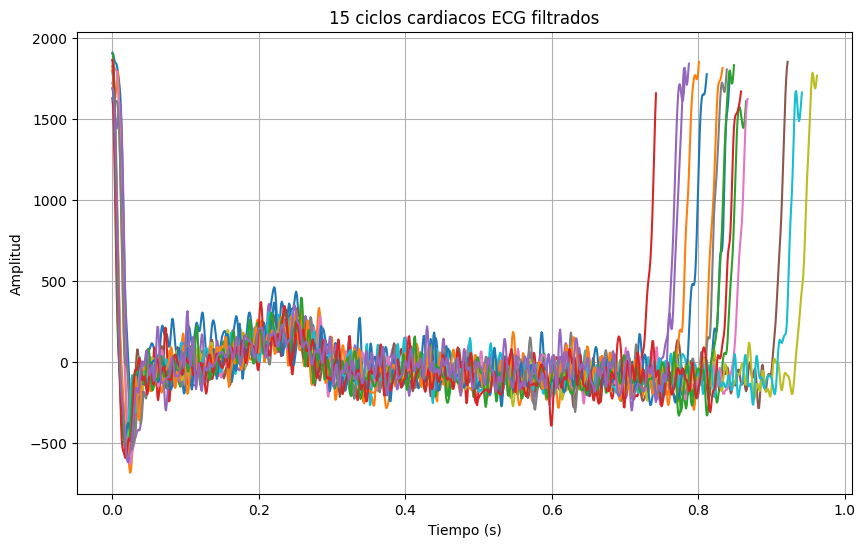

In [56]:
#Se grafican los ciclos, en una sola grafica para que se observe mas facil las diferencias entre cada uno.
plt.figure(figsize=(10,6))

for i, ciclo in enumerate(ciclos):
    t_ciclo = np.arange(len(ciclo))/fs
    plt.plot(t_ciclo, ciclo)

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("15 ciclos cardiacos ECG filtrados")
plt.grid()
plt.show()

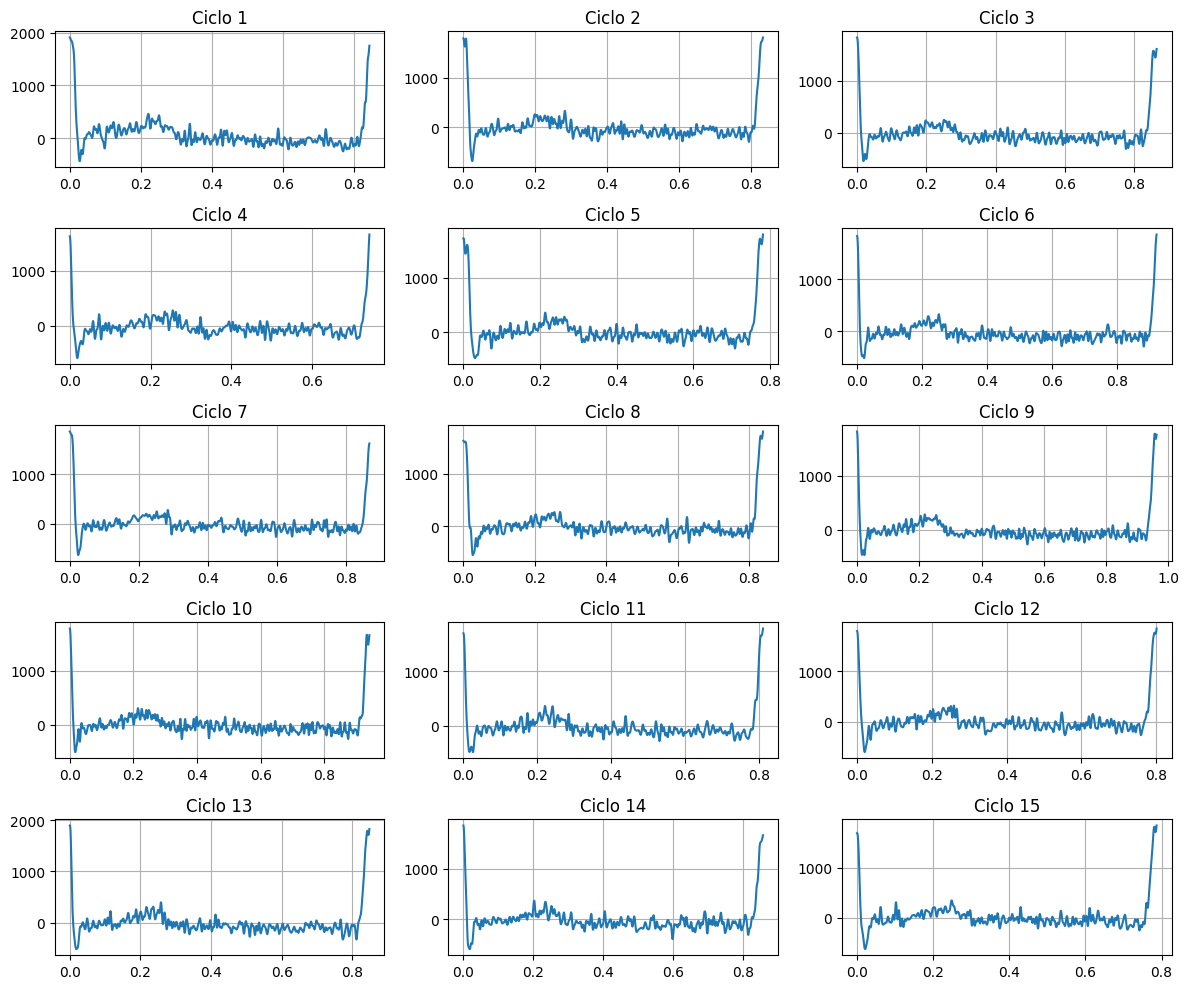

In [57]:
#Se vuelven a graficar los 15 ciclos pero esta vez, se grafican cada uno a parte.
plt.figure(figsize=(12,10))

for i, ciclo in enumerate(ciclos):
    
    t_ciclo = np.arange(len(ciclo))/fs
    
    plt.subplot(5,3,i+1)
    plt.plot(t_ciclo, ciclo)
    plt.title(f"Ciclo {i+1}")
    plt.grid()

plt.tight_layout()
plt.show()

# **4) Analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?**

R/ Al observar las gráficas de los 15 ciclos cardíacos se aprecia que la forma general del ECG se mantiene similar entre ciclos, especialmente la presencia del complejo QRS y la estructura temporal del latido, no obstante, se logra obsevar un leve cambio en cada uno de los ciclos, por ende, se puede concluir que, la dinámica fisiológica del corazón es relativamente estable, pero sus metricas estadisticas no.

Al analizar las metricas de los ciclos mostrados se oberva que, aunque la morfología del ECG es similar entre latidos, las estadísticas no se mantienen completamente constantes. Los promedios varían entre −28 y 74, lo cual es evidencia clara que el promedio no permance contante entre ciclos y que ademas tiene un rango de varianza considerable. Asi mimso, la varianza fluctúa entre casi un factor de 2.5 entre algunos ciclos, lo que evidencia cambios en la dispersión de la señal. Estas varianzas entre las metricas se pueden explicar por medio del comportamiento humano y las condiciones fisiológicas, ya que estas cambian con el tiempo y afectan a la forma de onda del ECG; Factores como el movimiento del paciente, el movimiento respiratorio y diversas interferencias contribuyen a este cambio, por ende una señal de ECG no puede considerarse estacionaria [4]. 

## Referencias

[4] A. I. Al-Shoshan and A. A. Al-Shoshan, “Biomedical Application of the Evolutionary Higher-Order Spectrum,” Computer Applications in Industry and Engineering, vol. 63, pp. 11–20, Sep. 2019, doi: 10.29007/XSD5.

In [58]:
#Se procede a realizar dos veces una prueba t entre dos ciclos, pero antes de, se procede a confirmar los supuestos de esta misma.

#Primera vez| Para esta vez, se usaran los ciclos 10 y 2, elegidos de manera aleatoria.
print("Primera vez, ciclos 2 vs 10\n")
print("----------------------------------|--------------------------------------|--------------------------------------|------------\n")
print("Numero de datos:")
for i, ciclo in enumerate(ciclos):
    if i+1 == 2 or i+1 == 10:
        print(f"Ciclo {i+1}: {len(ciclo)} datos\n")

print("----------------------------------|--------------------------------------|--------------------------------------|------------\n")

#Con el numero de datos se sabe que tipo de prueba de normalidad usar, la prueba de Shapiro-Wilk se recomienda usar entre 3 a 5000 muestras.
#Para este caso se usara esta.
print("Resultado prueba Shapiro-Wilk:")
from scipy.stats import shapiro # Se importa la prueba de normalidad

for i, ciclo in enumerate(ciclos):
    if i+1 == 2 or i+1 == 10:
        stat, p = shapiro(ciclo)
        
        print(f"Ciclo {i+1}")
        print(f"p-valor: {p}")
        
        if p > 0.05:
            print("Se puede asumir normalidad\n")
        else:
            print("No sigue una distribución normal\n")
print("----------------------------------|--------------------------------------|--------------------------------------|------------")
#Ya con este resulato, se puede concluir que no se puede hacer una prueba t, por ende, se debe hacer una prueba U de Mann-Whitney
from scipy.stats import mannwhitneyu
print("Resultados prueba U de Mann-Whitney:")
ciclo1 = ciclos[1]   # ciclo 8
ciclo2 = ciclos[9]   # ciclo 10

stat, p = mannwhitneyu(ciclo1, ciclo2, alternative='two-sided')

print("p-valor:", p)

if p > 0.05:
    print("Resultado: No hay diferencia estadística entre los ciclos")
else:
    print("Resultado: Existe diferencia estadística entre los ciclos")
#Se procede a realizar dos veces una prueba t entre dos ciclos, pero antes de, se procede a confirmar los supuestos de esta misma.
print("----------------------------------|--------------------------------------|--------------------------------------|------------\n")

#---------------------------------------------------------------------------------------------------------------
#Segunda vez| Para esta vez, se usaran los ciclos 5 y 14, elegidos de manera aleatoria.
print("Segunda vez, ciclos 5 vs 14\n")
print("----------------------------------|--------------------------------------|--------------------------------------|------------\n")
print("Numero de datos:")
for i, ciclo in enumerate(ciclos):
    if i+1 == 5 or i+1 == 14:
        print(f"Ciclo {i+1}: {len(ciclo)} datos\n")

print("----------------------------------|--------------------------------------|--------------------------------------|------------\n")

#Con el numero de datos se sabe que tipo de prueba de normalidad usar, la prueba de Shapiro-Wilk se recomienda usar entre 3 a 5000 muestras.
#Para este caso se usara esta.
print("Resultados prueba Shapiro-Wilk:")
from scipy.stats import shapiro # Se importa la prueba de normalidad

for i, ciclo in enumerate(ciclos):
    if i+1 == 5 or i+1 == 14:
        stat, p = shapiro(ciclo)
        
        print(f"Ciclo {i+1}")
        print(f"p-valor: {p}")
        
        if p > 0.05:
            print("Se puede asumir normalidad\n")
        else:
            print("No sigue una distribución normal\n")
print("----------------------------------|--------------------------------------|--------------------------------------|------------\n")
#Ya con este resulato, se puede concluir que no se puede hacer una prueba t, por ende, se debe hacer una prueba U de Mann-Whitney
from scipy.stats import mannwhitneyu
print("Resultados prueba U de Mann-Whitney:")
ciclo1 = ciclos[4]   # ciclo 5
ciclo2 = ciclos[13]   # ciclo 14

stat, p = mannwhitneyu(ciclo1, ciclo2, alternative='two-sided')

print("p-valor:", p)

if p > 0.05:
    print("Resultado: No hay diferencia estadística entre los ciclos")
else:
    print("Resultado: Existe diferencia estadística entre los ciclos")




Primera vez, ciclos 2 vs 10

----------------------------------|--------------------------------------|--------------------------------------|------------

Numero de datos:
Ciclo 2: 854 datos

Ciclo 10: 965 datos

----------------------------------|--------------------------------------|--------------------------------------|------------

Resultado prueba Shapiro-Wilk:
Ciclo 2
p-valor: 4.438228165718927e-42
No sigue una distribución normal

Ciclo 10
p-valor: 6.518300365348172e-44
No sigue una distribución normal

----------------------------------|--------------------------------------|--------------------------------------|------------
Resultados prueba U de Mann-Whitney:
p-valor: 5.66945499522471e-07
Resultado: Existe diferencia estadística entre los ciclos
----------------------------------|--------------------------------------|--------------------------------------|------------

Segunda vez, ciclos 5 vs 14

----------------------------------|--------------------------------------|

# **5) Analisis de las pruebas.**

R/ Para esta parte, se realizo como primero, una prueba de normalidad de Shapiro-Wilk, luego de haber comprobado el numero de datos, el resultado de esta prueba demostro que los datos de todos los ciclos no seguian una distribucion normal, por ende, empleo la prueba de U de Mann-Whitney, los valores obtentidos para la comparacion de los ciclos 2 vs 10 y 5 vs 14 dicen que hay diferencias estadisticas entre los ciclos, lo que concluye en que NO hay estacionaridad entre los ciclos evaluados.

In [62]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(ecg_filt)

print("Estadístico ADF:", resultado[0])
print("p-valor:", "{:.10f}".format(resultado[1]))

print("Valores críticos:")
for clave, valor in resultado[4].items():
    print(clave, ":", valor)

if resultado[1] <= 0.05:
    print("Resultado: Se rechaza H0 → la señal es estacionaria")
else:
    print("Resultado: No se rechaza H0 → la señal no es estacionaria")

Estadístico ADF: -26.61245296603898
p-valor: 0.0000000000
Valores críticos:
1% : -3.4305630243276717
5% : -2.861634151073544
10% : -2.5668201137295887
Resultado: Se rechaza H0 → la señal es estacionaria
